In [1]:
# Setup & Imports
import sys
sys.path.insert(0, '../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import get_ipython

from src.utils.config import get_config
from src.utils.db import get_db

# Configure plotting
plt.style.use('dark_background')
sns.set_palette("husl")
get_ipython().run_line_magic('matplotlib', 'inline')

# Initialize connections
config = get_config()
db = get_db()

print(f"Environment: {config.environment}")
print(f"Database: Connected")

2026-05-17 17:52:20 [info     ] database_initialized           database=postgres host=aws-0-eu-west-1.pooler.supabase.com pool_size=10 ssl_mode=require
Environment: Environment.DEVELOPMENT
Database: Connected


In [2]:
# SHAP Analysis Setup
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not installed. Install with: pip install shap")

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from src.models.train import F1ModelTrainer
from pathlib import Path

trainer = F1ModelTrainer()

# metrics file for xgboost winner
metrics_dir = Path("artifacts/metrics")
metrics_files = list(metrics_dir.glob("xgboost_winner_*.json"))

if metrics_files:
    # Get the most recent file
    latest_metrics = max(metrics_files, key=lambda x: x.stat().st_mtime)
    print(f"Loading: {latest_metrics.name}")
    model_bundle = trainer.io.read_json(latest_metrics)
    print(" Metrics loaded successfully")
else:
    print("No metrics files found for xgboost winner")

Loading: xgboost_winner_20260517_141244.json
 Metrics loaded successfully


Loading model: xgboost_winner_20260517_134824.pkl
2026-05-17 18:05:59 [debug    ] sql_query_executing            parameters={'year_0': 2025} statement='\n        SELECT \n            f.*,\n            r.year,\n            r.round,\n            r.date as race_date\n        FROM driver_race_features f\n        JOIN races r ON f.race_id = r.race_id\n        WHE'
2026-05-17 18:06:00 [debug    ] database_transaction_committed
2026-05-17 18:06:00 [info     ] training_data_loaded           features=26 rows=479 years=[2025]
Computing SHAP values...


C:\Users\user\AppData\Local\Temp\ipykernel_3616\942936926.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = df[available_features].fillna(0)


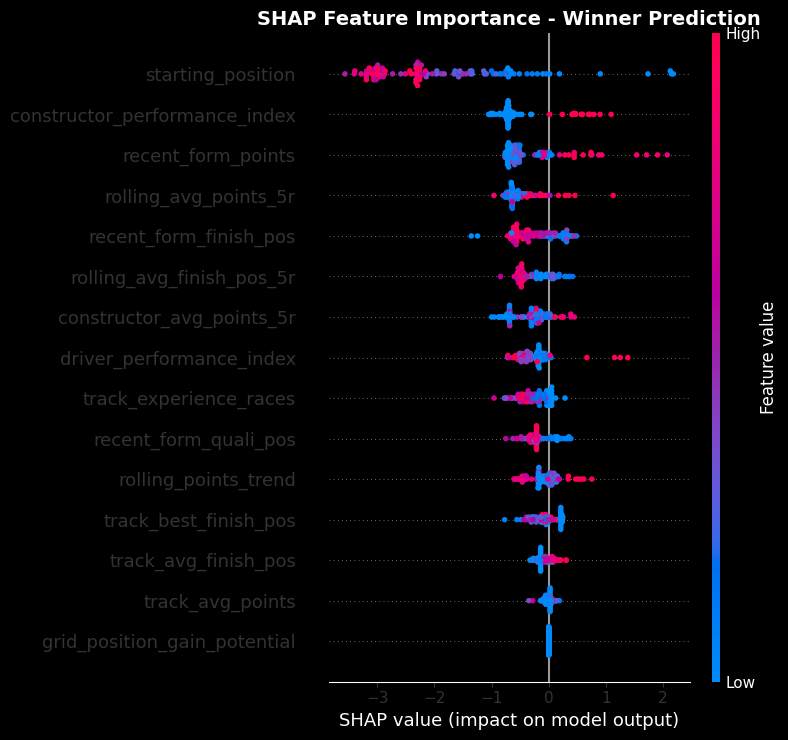

<Figure size 1000x600 with 0 Axes>

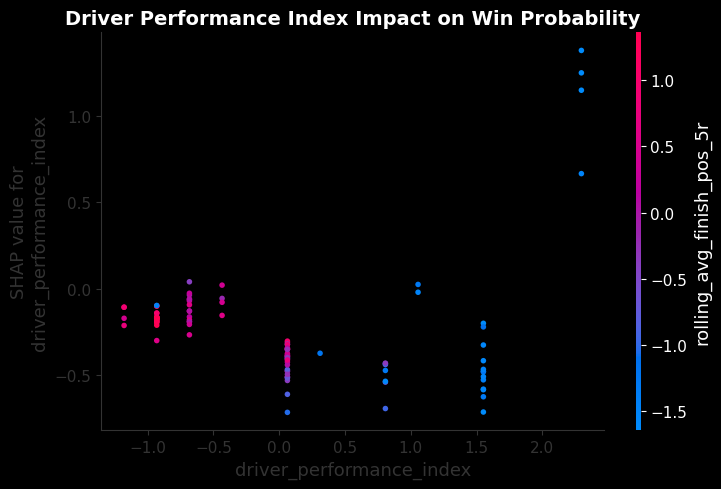


SAMPLE PREDICTION EXPLANATION (First driver in test set)


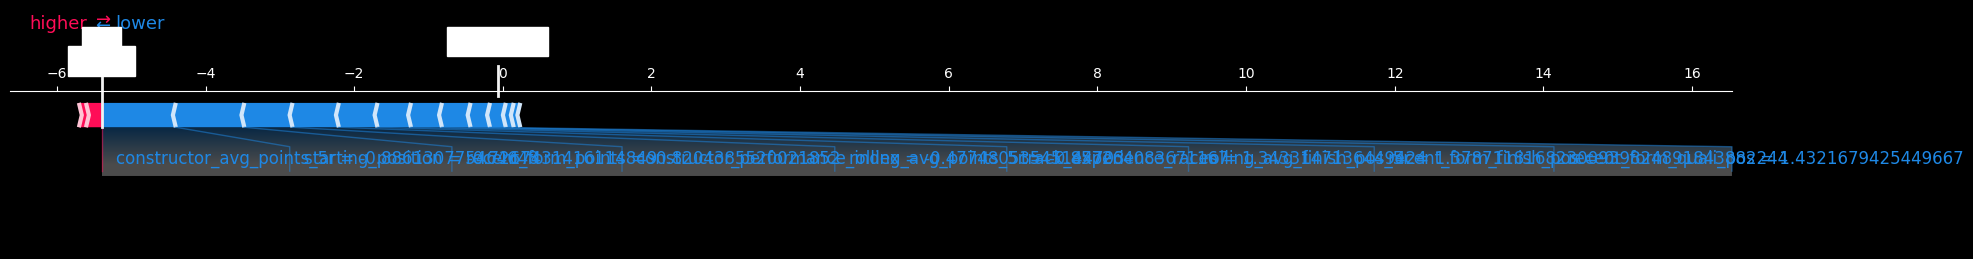

In [9]:
# SHAP Explainability
import shap
import pickle
from pathlib import Path

SHAP_AVAILABLE = True

if SHAP_AVAILABLE:
    import xgboost as xgb
    
    # Find the latest model file 
    model_dir = Path("../artifacts/models")
    model_files = list(model_dir.glob("xgboost_winner_*.pkl"))
    
    if model_files:
        # Get the most recent model file
        model_path = max(model_files, key=lambda x: x.stat().st_mtime)
        print(f"Loading model: {model_path.name}")
        
        with open(model_path, 'rb') as f:
            bundle = pickle.load(f)
        
        model = bundle['model']
        scaler = bundle['scaler']
        
        # Load sample data
        df = trainer.load_training_data([2025])
        
        available_features = [c for c in trainer.FEATURE_COLS if c in df.columns]
        X = df[available_features].fillna(0)
        X_scaled = scaler.transform(X)
        
        # SHAP analysis
        print("Computing SHAP values...")
        explainer = shap.TreeExplainer(model)
        
        # smaller sample for faster computation
        sample_size = min(100, len(X_scaled))
        shap_values = explainer.shap_values(X_scaled[:sample_size])
        
        # Summary plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(
            shap_values,
            X_scaled[:sample_size],
            feature_names=available_features,
            show=False,
            max_display=15
        )
        plt.title('SHAP Feature Importance - Winner Prediction', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Dependence plot for top feature
        if 'driver_performance_index' in available_features:
            feature_idx = available_features.index('driver_performance_index')
            plt.figure(figsize=(10, 6))
            shap.dependence_plot(
                feature_idx,
                shap_values,
                X_scaled[:sample_size],
                feature_names=available_features,
                show=False
            )
            plt.title('Driver Performance Index Impact on Win Probability', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
        else:
            feature_importances = bundle.get('metrics', {}).get('feature_importance', {})
            if feature_importances:
                top_feature = list(feature_importances.keys())[0]
                if top_feature in available_features:
                    feature_idx = available_features.index(top_feature)
                    plt.figure(figsize=(10, 6))
                    shap.dependence_plot(
                        feature_idx,
                        shap_values,
                        X_scaled[:sample_size],
                        feature_names=available_features,
                        show=False
                    )
                    plt.title(f'{top_feature} Impact on Win Probability', fontsize=14, fontweight='bold')
                    plt.tight_layout()
                    plt.show()
        
        # To see why a specific driver was predicted to win
        if len(X_scaled) > 0:
            print("\n" + "="*60)
            print("SAMPLE PREDICTION EXPLANATION (First driver in test set)")
            print("="*60)
            shap.force_plot(
                explainer.expected_value,
                shap_values[0,:],
                X_scaled[0,:],
                feature_names=available_features,
                matplotlib=True,
                show=False
            )
            plt.tight_layout()
            plt.show()
            
    else:
        print("No XGBoost winner model found in artifacts/models/")
        print("Available model files:")
        for f in model_dir.glob("*.pkl"):
            print(f"  {f.name}")

In [ ]:
# Interpretation Guidelines
print("""


1. DRIVER PERFORMANCE INDEX
   - Primary predictor of race outcomes
   - Combines points, finish positions, and consistency
   - Higher values strongly correlate with winning

2. CONSTRUCTOR PERFORMANCE INDEX
   - Team strength indicator
   - Critical for predicting podium finishes
   - Less important than driver skill for outright wins

3. QUALIFYING POSITION
   - Strong predictor but not deterministic
   - Grid position advantage diminishes over race distance
   - Overtaking tracks reduce qualifying impact

4. TRACK EXPERIENCE
   - Moderate impact on consistent performers
   - Diminishing returns after 5+ races at circuit
   - More important on technical tracks

5. DNF PROBABILITY
   - Negative predictor (higher = worse outcome)
   - Mechanical reliability critical for championship
   - Driver error DNFs less predictable

- Use XGBoost for final predictions (best F1 score)
- Threshold 0.5 for balanced betting strategy
- Threshold 0.7 for conservative recommendations
- Always consider weather and track conditions
- Monitor model drift between seasons
""")




1. DRIVER PERFORMANCE INDEX
   - Primary predictor of race outcomes
   - Combines points, finish positions, and consistency
   - Higher values strongly correlate with winning

2. CONSTRUCTOR PERFORMANCE INDEX
   - Team strength indicator
   - Critical for predicting podium finishes
   - Less important than driver skill for outright wins

3. QUALIFYING POSITION
   - Strong predictor but not deterministic
   - Grid position advantage diminishes over race distance
   - Overtaking tracks reduce qualifying impact

4. TRACK EXPERIENCE
   - Moderate impact on consistent performers
   - Diminishing returns after 5+ races at circuit
   - More important on technical tracks

5. DNF PROBABILITY
   - Negative predictor (higher = worse outcome)
   - Mechanical reliability critical for championship
   - Driver error DNFs less predictable

=== BUSINESS RECOMMENDATIONS ===

- Use XGBoost for final predictions (best F1 score)
- Threshold 0.5 for balanced betting strategy
- Threshold 0.7 for conservat

In [13]:
import pickle
from pathlib import Path
from datetime import datetime
import shap
import matplotlib.pyplot as plt

explain_dir = Path("artifacts/explainability")
explain_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Collect all important objects from your analysis
explainability_bundle = {}

# Add SHAP objects if they exist
if 'explainer' in dir():
    explainability_bundle['explainer'] = explainer
    print(" Captured SHAP explainer")

if 'shap_values' in dir():
    explainability_bundle['shap_values'] = shap_values
    print(" Captured SHAP values")

if 'model' in dir():
    explainability_bundle['model'] = model
    print(" Captured model")

if 'scaler' in dir():
    explainability_bundle['scaler'] = scaler
    print(" Captured scaler")

if 'X_scaled' in dir():
    explainability_bundle['X_scaled'] = X_scaled
    print(" Captured scaled features")

if 'feature_names' in dir():
    explainability_bundle['feature_names'] = feature_names
    print(" Captured feature names")

# Add metrics if available
if 'bundle' in dir() and isinstance(bundle, dict):
    if 'metrics' in bundle:
        explainability_bundle['metrics'] = bundle['metrics']
        print(" Captured metrics")

# Add SHAP expectation value
if hasattr(explainer, 'expected_value'):
    explainability_bundle['expected_value'] = explainer.expected_value
    print(" Captured expected value")

# Save everything
bundle_path = explain_dir / f"explainability_bundle_{timestamp}.pkl"
with open(bundle_path, 'wb') as f:
    pickle.dump(explainability_bundle, f)

print(f"\n Saved explainability analysis to: {bundle_path}")
print(f"   Size: {bundle_path.stat().st_size / 1024:.1f} KB")
print(f"   Contains: {', '.join(explainability_bundle.keys())}")

 Captured SHAP explainer
 Captured SHAP values
 Captured model
 Captured scaler
 Captured scaled features
 Captured metrics
 Captured expected value

 Saved explainability analysis to: artifacts\explainability\explainability_bundle_20260517_181116.pkl
   Size: 857.2 KB
   Contains: explainer, shap_values, model, scaler, X_scaled, metrics, expected_value
